<a href="https://colab.research.google.com/github/hasniaina/glassmorphism-card-responsive/blob/main/testexam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Distribution des classes :
x_wins : x_wins
1    0.668127
0    0.331873
Name: proportion, dtype: float64
is_draw: is_draw
0    0.838992
1    0.161008
Name: proportion, dtype: float64

=== ÉTAPE 2 : Baseline Logistic Regression ===

Modèle x_wins
Accuracy : 0.6998904709748083
F1-score : 0.7965346534653466
              precision    recall  f1-score   support

           0       0.58      0.34      0.43       909
           1       0.73      0.88      0.80      1830

    accuracy                           0.70      2739
   macro avg       0.66      0.61      0.61      2739
weighted avg       0.68      0.70      0.67      2739


Modèle is_draw
Accuracy : 0.8389923329682366
F1-score : 0.0
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2298
           1       0.00      0.00      0.00       441

    accuracy                           0.84      2739
   macro avg       0.42      0.50      0.46      2739
weighted avg       0.70      0.84  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


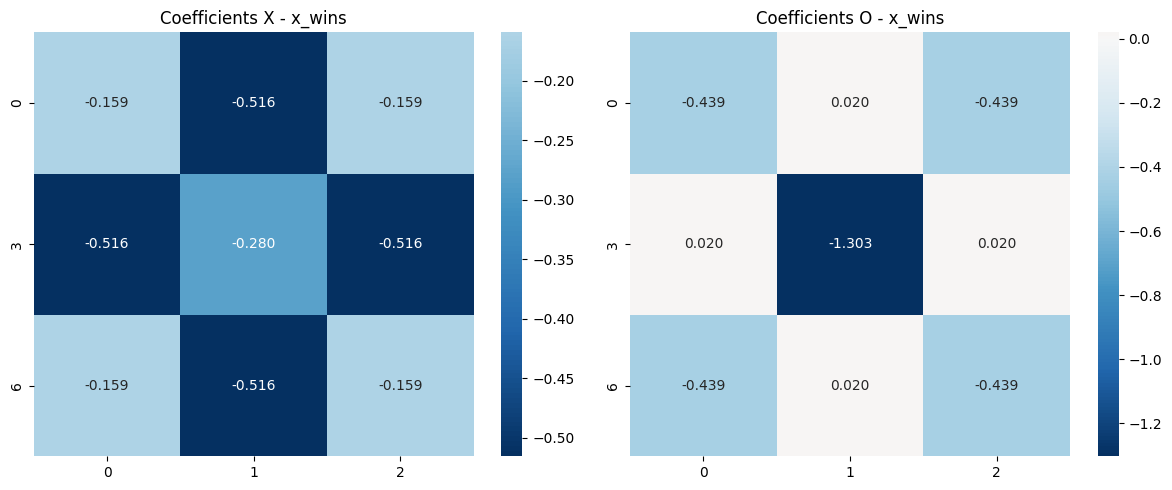

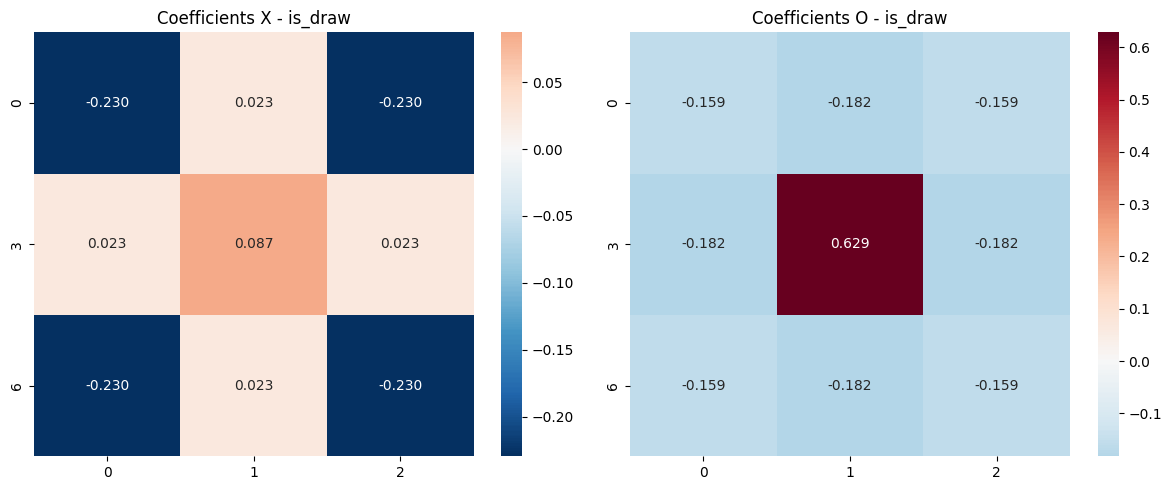


Top |coeff| pour x_wins : c4_o    1.303262
c1_x    0.515674
c5_x    0.515674
c7_x    0.515674
c3_x    0.515674
c0_o    0.439453
c6_o    0.439453
c2_o    0.439453
dtype: float64

Top |coeff| pour is_draw : c4_o    0.628852
c0_x    0.229690
c2_x    0.229690
c6_x    0.229690
c8_x    0.229690
c1_o    0.182231
c5_o    0.182231
c3_o    0.182231
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# ====================== CHARGEMENT DES DONNÉES ======================
df = pd.read_csv('dataMorpion.csv')
feature_cols = [f'c{i}_x' for i in range(9)] + [f'c{i}_o' for i in range(9)]
X = df[feature_cols]
y_xwins = df['x_wins']
y_draw  = df['is_draw']

print("Distribution des classes :")
print("x_wins :", y_xwins.value_counts(normalize=True))
print("is_draw:", y_draw.value_counts(normalize=True))

# ====================== ÉTAPE 2 — BASELINE LOGISTIC REGRESSION ======================
print("\n=== ÉTAPE 2 : Baseline Logistic Regression ===")

# Modèle 1 : x_wins
lr_x = LogisticRegression(max_iter=1000, random_state=42)
lr_x.fit(X, y_xwins)
pred_x = lr_x.predict(X)

print("\nModèle x_wins")
print("Accuracy :", accuracy_score(y_xwins, pred_x))
print("F1-score :", f1_score(y_xwins, pred_x))
print(classification_report(y_xwins, pred_x))

# Modèle 2 : is_draw
lr_d = LogisticRegression(max_iter=1000, random_state=42)
lr_d.fit(X, y_draw)
pred_d = lr_d.predict(X)

print("\nModèle is_draw")
print("Accuracy :", accuracy_score(y_draw, pred_d))
print("F1-score :", f1_score(y_draw, pred_d))
print(classification_report(y_draw, pred_d))

# ====================== ANALYSE DES COEFFICIENTS (obligatoire) ======================
def plot_coefficients(model, target_name):
    coeffs = model.coef_[0]
    c_x = coeffs[:9].reshape(3, 3)
    c_o = coeffs[9:].reshape(3, 3)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(c_x, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax[0],
                xticklabels=['0','1','2'], yticklabels=['0','3','6'])
    ax[0].set_title(f'Coefficients X - {target_name}')

    sns.heatmap(c_o, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax[1],
                xticklabels=['0','1','2'], yticklabels=['0','3','6'])
    ax[1].set_title(f'Coefficients O - {target_name}')
    plt.tight_layout()
    plt.show()

print("\nCartes des coefficients :")
plot_coefficients(lr_x, "x_wins")
plot_coefficients(lr_d, "is_draw")

# Top coefficients
print("\nTop |coeff| pour x_wins :",
      pd.Series(lr_x.coef_[0], index=feature_cols).abs().sort_values(ascending=False).head(8))
print("\nTop |coeff| pour is_draw :",
      pd.Series(lr_d.coef_[0], index=feature_cols).abs().sort_values(ascending=False).head(8))

In [ ]:
print("\n=== ÉTAPE 3 : Modèles Avancés ===")

models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")

    # x_wins
    model.fit(X, y_xwins)
    pred = model.predict(X)
    results[f"{name}_xwins"] = {
        "Acc": accuracy_score(y_xwins, pred),
        "F1": f1_score(y_xwins, pred)
    }
    print(f"x_wins → Acc: {results[f'{name}_xwins']['Acc']:.4f} | F1: {results[f'{name}_xwins']['F1']:.4f}")

    # is_draw
    model.fit(X, y_draw)  # on ré-entraîne sur l'autre cible
    pred = model.predict(X)
    results[f"{name}_draw"] = {
        "Acc": accuracy_score(y_draw, pred),
        "F1": f1_score(y_draw, pred)
    }
    print(f"is_draw → Acc: {results[f'{name}_draw']['Acc']:.4f} | F1: {results[f'{name}_draw']['F1']:.4f}")


=== ÉTAPE 3 : Modèles Avancés ===

--- DecisionTree ---
x_wins → Acc: 0.8496 | F1: 0.8908
is_draw → Acc: 0.8938 | F1: 0.6216

--- RandomForest ---
x_wins → Acc: 0.9956 | F1: 0.9967
is_draw → Acc: 0.9883 | F1: 0.9624

--- XGBoost ---
x_wins → Acc: 1.0000 | F1: 1.0000
is_draw → Acc: 1.0000 | F1: 1.0000

--- MLP ---
x_wins → Acc: 1.0000 | F1: 1.0000
is_draw → Acc: 1.0000 | F1: 1.0000


## Front

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

xgb_xwins = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                          random_state=42, eval_metric='logloss')
xgb_xwins.fit(X, y_xwins)
joblib.dump(xgb_xwins, 'models/xgb_xwins.joblib')

xgb_draw = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                         random_state=42, eval_metric='logloss')
xgb_draw.fit(X, y_draw)
joblib.dump(xgb_draw, 'models/xgb_draw.joblib')

print("✅ Modèles XGBoost sauvegardés !")

✅ Modèles XGBoost sauvegardés !


Front

In [ ]:
# ====================== INTERFACE JOABLE COLAB (Étape 4) - VERSION CORRIGÉE ======================
import ipywidgets as widgets
from IPython.display import display, clear_output
import joblib
import random

# --- Fonctions utilitaires ---
def get_winner(board):
    wins = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]]
    for a,b,c in wins:
        if board[a] == board[b] == board[c] != 0:
            return board[a]
    return None

def is_full(board):
    return all(x != 0 for x in board)

def board_to_features(board):
    features = []
    for cell in board:
        features.append(1 if cell == 1 else 0)
        features.append(1 if cell == -1 else 0)
    return features

def predict_value(board, player_to_move, model_xwins, model_draw):
    """Score avantage du joueur courant (entre -1 et +1)"""
    features = board_to_features(board)
    p_xwins = model_xwins.predict_proba([features])[0][1]
    p_draw = model_draw.predict_proba([features])[0][1]
    p_o_win = 1 - p_xwins - p_draw
    if player_to_move == 'X':
        return p_xwins * 1.0 + p_draw * 0.0 + p_o_win * (-1.0)
    else:
        return p_o_win * 1.0 + p_draw * 0.0 + p_xwins * (-1.0)

# --- Minimax Hybride (inchangé) ---
def minimax_hybrid(board, depth, is_max, alpha, beta, model_xwins, model_draw):
    winner = get_winner(board)
    if winner == 1: return 1, None
    if winner == -1: return -1, None
    if is_full(board): return 0, None
    if depth == 0:
        player = 'X' if is_max else 'O'
        return predict_value(board, player, model_xwins, model_draw), None

    best_move = None
    if is_max:
        best_score = -float('inf')
        for i in range(9):
            if board[i] == 0:
                board[i] = 1
                score, _ = minimax_hybrid(board, depth-1, False, alpha, beta, model_xwins, model_draw)
                board[i] = 0
                if score > best_score:
                    best_score = score
                    best_move = i
                alpha = max(alpha, score)
                if beta <= alpha: break
        return best_score, best_move
    else:
        best_score = float('inf')
        for i in range(9):
            if board[i] == 0:
                board[i] = -1
                score, _ = minimax_hybrid(board, depth-1, True, alpha, beta, model_xwins, model_draw)
                board[i] = 0
                if score < best_score:
                    best_score = score
                    best_move = i
                beta = min(beta, score)
                if beta <= alpha: break
        return best_score, best_move

# ====================== CHARGEMENT MODÈLES ======================
model_xwins = joblib.load('models/xgb_xwins.joblib')
model_draw  = joblib.load('models/xgb_draw.joblib')

# ====================== INTERFACE ======================
board = [0] * 9
current_player = 'X'
game_over = False
mode = 'human'

buttons = []
for i in range(9):
    btn = widgets.Button(description=' ', layout=widgets.Layout(width='80px', height='80px', font_size='30px'))
    btn.style.button_color = 'white'
    buttons.append(btn)

grid = widgets.GridBox(children=buttons, layout=widgets.Layout(grid_template_columns="repeat(3, 1fr)", width='300px'))

mode_selector = widgets.Dropdown(options=['vs Human', 'vs IA (ML)', 'vs IA (Hybride)'],
                                 value='vs Human', description='Mode :')

status = widgets.Label(value="X commence - Mode Human", layout=widgets.Layout(width='100%'))

new_game_btn = widgets.Button(description="Nouvelle Partie", button_style='success')
quit_btn = widgets.Button(description="Quitter", button_style='danger')
output = widgets.Output()

def update_board_display():
    for i in range(9):
        if board[i] == 1:
            buttons[i].description = 'X'
            buttons[i].style.button_color = '#ff4444'
        elif board[i] == -1:
            buttons[i].description = 'O'
            buttons[i].style.button_color = '#4444ff'
        else:
            buttons[i].description = ' '
            buttons[i].style.button_color = 'white'

def check_end():
    global game_over
    winner = get_winner(board)
    if winner == 1:
        status.value = "🎉 X gagne !"
        game_over = True
    elif winner == -1:
        status.value = "O gagne !"
        game_over = True
    elif is_full(board):
        status.value = "Match nul !"
        game_over = True
    return game_over

def make_move(pos):
    global current_player, game_over
    if game_over or board[pos] != 0:
        return
    board[pos] = 1 if current_player == 'X' else -1
    update_board_display()
    if check_end():
        return
    current_player = 'O' if current_player == 'X' else 'X'
    status.value = f"{current_player} joue — {mode_selector.value}"

    if mode != 'human' and current_player == 'X':
        with output:
            clear_output(wait=True)
            print("IA réfléchit...")
        ai_move()

# ====================== IA ALÉATOIRE (NOUVEAUTÉ) ======================
def ai_move():
    global current_player
    if mode == 'ml':
        best_score = -float('inf')
        best_positions = []
        for i in range(9):
            if board[i] == 0:
                temp = board[:]
                temp[i] = 1
                # Correction importante : on veut maximiser l'avantage de X
                score = -predict_value(temp, 'O', model_xwins, model_draw)
                if score > best_score:
                    best_score = score
                    best_positions = [i]
                elif score == best_score:
                    best_positions.append(i)
        if best_positions:
            chosen = random.choice(best_positions)
            make_move(chosen)

    elif mode == 'hybrid':
        best_score = -float('inf')
        best_positions = []
        for i in range(9):
            if board[i] == 0:
                temp_board = board[:]
                temp_board[i] = 1
                # Appel minimax avec profondeur restante (depth=2 car un coup déjà joué)
                score, _ = minimax_hybrid(temp_board, depth=2, is_max=False,
                                          alpha=-float('inf'), beta=float('inf'),
                                          model_xwins=model_xwins, model_draw=model_draw)
                if score > best_score:
                    best_score = score
                    best_positions = [i]
                elif score == best_score:
                    best_positions.append(i)
        if best_positions:
            chosen = random.choice(best_positions)
            make_move(chosen)

def on_button_click(b):
    pos = buttons.index(b)
    make_move(pos)

for btn in buttons:
    btn.on_click(on_button_click)

def new_game(_):
    global board, current_player, game_over, mode
    board = [0] * 9
    current_player = 'X'
    game_over = False
    mode = {'vs Human': 'human', 'vs IA (ML)': 'ml', 'vs IA (Hybride)': 'hybrid'}[mode_selector.value]
    update_board_display()
    status.value = f"X commence — {mode_selector.value}"
    if mode != 'human':
        ai_move()  # IA commence (maintenant aléatoire si égalité)

new_game_btn.on_click(new_game)

# Affichage
display(widgets.VBox([
    widgets.HTML("<h2>Morpion IA - ISPM Hackathon</h2>"),
    mode_selector,
    grid,
    status,
    widgets.HBox([new_game_btn, quit_btn]),
    output
]))

# Lancer la première partie
new_game(None)